
# Initialization of data



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

coordinates_df = pd.read_csv('/content/drive/MyDrive/DL_Project_June/Datasets/coordinates.csv', header=None, index_col=False, sep=';')
# header= none: we don't have col names in the first raw
# index_col: we don't have a col for the index
print(coordinates_df.head(), coordinates_df.shape)



# Forces:
forces_df_raw = pd.read_csv('/content/drive/MyDrive/DL_Project_June/Datasets/forces.csv', header=None, index_col=False, sep=None, engine='python')
# sep = none means pandas will search to find the separator
forces_df = forces_df_raw[0].str.split('\t', expand=True)
forces_df = forces_df.apply(pd.to_numeric, errors='coerce')
print(forces_df.head(), forces_df.shape)

# velocity:
velocities_df_raw = pd.read_csv('/content/drive/MyDrive/DL_Project_June/Datasets/velocity.csv', header=None, index_col=False, sep=None, engine='python')
velocities_df = velocities_df_raw[0].str.split('\t', expand=True)
velocities_df = velocities_df.apply(pd.to_numeric, errors='coerce')
print(velocities_df.head(), velocities_df.shape)

     0        1        2        3        4        5        6        7    \
0  0.000  56.3980  51.9370  52.6880  56.3750  52.0050  52.6170  56.4260   
1  0.002  56.3992  51.9368  52.6877  56.3743  52.0037  52.6162  56.4267   
2  0.004  56.3999  51.9366  52.6871  56.3767  52.0046  52.6161  56.4285   
3  0.006  56.4001  51.9364  52.6861  56.3816  52.0073  52.6167  56.4315   
4  0.008  56.4001  51.9362  52.6848  56.3876  52.0109  52.6179  56.4350   

       8        9    ...      405      406      407      408      409  \
0  51.8530  52.6400  ...  52.1880  56.7460  52.0040  52.3850  56.7650   
1  51.8556  52.6344  ...  52.1872  56.7448  52.0025  52.3849  56.7651   
2  51.8579  52.6307  ...  52.1890  56.7434  52.0011  52.3842  56.7652   
3  51.8594  52.6288  ...  52.1930  56.7417  52.0001  52.3832  56.7652   
4  51.8597  52.6288  ...  52.1982  56.7402  51.9995  52.3824  56.7651   

       410      411      412      413      414  
0  51.9040  52.4540  56.7550  52.1200  52.4210  
1  51.9044  

Seeting the seeds:

In [3]:
import numpy as np
import tensorflow as tf
import random
import os

def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_all_seeds(42)


1- Drop the first column (timesteps)

In [4]:
# 1- Drop the first column (timesteps)
coords = coordinates_df.iloc[:, 1:].values
vels   = velocities_df.iloc[:, 1:].values
forces = forces_df.iloc[:, 1:].values
print("\nAfter removing first column:")
print("Coordinates:", coords.shape)
print("Velocities :", vels.shape)
print("Forces     :", forces.shape)

# 2-  RESHAPE TO (timesteps, atoms, xyz)
NUM_ATOMS = 138

coords = coords.reshape(-1, NUM_ATOMS, 3)
vels   = vels.reshape(-1, NUM_ATOMS, 3)
forces = forces.reshape(-1, NUM_ATOMS, 3)

print("\nAfter reshape:")
print("Coordinates:", coords.shape)
print("Velocities :", vels.shape)
print("Forces     :", forces.shape)

#3- Concatenate Features to be [x,y,z,vx,vy,vz,fx,fy,fz]
import numpy as np
features = np.concatenate(
    [coords, vels, forces],
    axis=-1
)

print("\nCombined features shape:")
print(features.shape)

# 4- Scale Features
#FIT SCALAR ON TRAINING DATA ONLY
from sklearn.preprocessing import StandardScaler

N         = len(features)       # 50001

train_end = int(N * 0.70)       # 35000
val_end   = int(N * 0.85)       # 42500

# Fit scaler on training data ONLY — prevents leakage from future frames
train_data = features[:train_end].reshape(-1, 9)   # (35000*138, 9)

scaler = StandardScaler()
scaler.fit(train_data)

def scale_data(data):
    T = data.shape[0]
    data_scaled = scaler.transform(data.reshape(-1, 9))
    return data_scaled.reshape(T, 138, 9).astype('float32')

# features shape = (50001,138,9)

features_scaled = scale_data(features)

print('Scaling is done')
print("Train mean:", features_scaled[:train_end].mean())
print("Val mean:", features_scaled[train_end:val_end].mean())
print("Test mean:", features_scaled[val_end:].mean())

features_scaled[:train_end].reshape(-1, 9).mean(axis=0)



After removing first column:
Coordinates: (50001, 414)
Velocities : (50001, 414)
Forces     : (50001, 414)

After reshape:
Coordinates: (50001, 138, 3)
Velocities : (50001, 138, 3)
Forces     : (50001, 138, 3)

Combined features shape:
(50001, 138, 9)
Scaling is done
Train mean: -7.6196365e-08
Val mean: -0.96301705
Test mean: -1.4792347


array([-6.7091067e-05, -1.6351226e-04,  1.4109928e-04,  2.3492939e-08,
        6.1220732e-08, -1.9674330e-08, -2.8648485e-11, -5.6235072e-10,
        5.2429877e-10], dtype=float32)

In [6]:
train_feat = features_scaled[:train_end]
val_feat   = features_scaled[train_end:val_end]
test_feat  = features_scaled[val_end:]
print(f'Train:{train_feat.shape} Val:{val_feat.shape} Test:{test_feat.shape}')

Train:(35000, 138, 9) Val:(7500, 138, 9) Test:(7501, 138, 9)


# Atom level Transformer #1

We designed an** Atom-Level Transformer** that processes each atom individually but gives it access to its **10 nearest neighbors** on each side (20 neighbors total, plus the atom itself = 21 atoms). For each atom i at each timestep, the input includes all 9 features (x, y, z, vx, vy, vz, fx, fy, fz) for atoms i-10 through i+10. The model predicts the feature delta for atom i only

It's working and learning well
val_loss is steadily decreasing from  0.421 -> 0.127. But each epoch takes 5 minutes and while I'm at epoch 21 of 30 the GPU resources is finished on Colab
So 1-Reduce atoms sampled per timestep 5   #  it was 20
2- Reduce temporal window: 5   # it was 10
3- Smaller model:


1- data generator

In [7]:
import tensorflow as tf
import numpy as np
SPATIAL_WINDOW = 10
T_WINDOW       = 5
ATOMS_IN       = 2 * SPATIAL_WINDOW + 1   # 21
F              = 9
BATCH_SIZE     = 128
N_ATOMS_SAMPLE = 5

def make_encdec_dataset(features_arr, t_window, spatial_window,
                         batch_size, n_atoms_sample=5, shuffle=False):
    N, A, Feat = features_arr.shape
    S = spatial_window
    padded = np.pad(features_arr, ((0,0),(S,S),(0,0)), mode='edge').astype(np.float32)

    def generator():
        timesteps = np.arange(t_window, N - 1)
        if shuffle:
            np.random.shuffle(timesteps)
        for t in timesteps:
            atoms = np.random.choice(A, size=n_atoms_sample, replace=False)
            for a in atoms:
                neighborhood = padded[t - t_window:t, a:a + 2*S + 1, :]
                x_enc = neighborhood.reshape(t_window, -1).astype(np.float32)  # (T,189)
                x_dec = features_arr[t, a, :].reshape(1, -1).astype(np.float32) # (1,9)
                y = (features_arr[t+1, a, :] - features_arr[t, a, :]).astype(np.float32)
                yield (x_enc, x_dec), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (tf.TensorSpec(shape=(T_WINDOW, ATOMS_IN * F), dtype=tf.float32),
             tf.TensorSpec(shape=(1, F),                   dtype=tf.float32)),
            tf.TensorSpec(shape=(F,), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    ds = ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_encdec_dataset(train_feat, T_WINDOW, SPATIAL_WINDOW, BATCH_SIZE, N_ATOMS_SAMPLE, shuffle=True)
val_ds   = make_encdec_dataset(val_feat,   T_WINDOW, SPATIAL_WINDOW, BATCH_SIZE, N_ATOMS_SAMPLE)
test_ds  = make_encdec_dataset(test_feat,  T_WINDOW, SPATIAL_WINDOW, BATCH_SIZE, N_ATOMS_SAMPLE)

n_train_steps = (len(train_feat) - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE
n_val_steps   = (len(val_feat)   - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE
n_test_steps  = (len(test_feat)  - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE

for (X_enc, X_dec), Y in train_ds.take(1):
    print('X_enc:', X_enc.shape)   # (128, 5, 189)
    print('X_dec:', X_dec.shape)   # (128, 1, 9)
    print('Y    :', Y.shape)       # (128, 9)
    print(f'Y mean={Y.numpy().mean():.6f} (should be ~0)')
print(f'Steps/epoch: train={n_train_steps} val={n_val_steps}')

X_enc: (128, 5, 189)
X_dec: (128, 1, 9)
Y    : (128, 9)
Y mean=-0.014475 (should be ~0)
Steps/epoch: train=1366 val=292


2- Transformer exactly as the prof

In [8]:
def positional_encoding(length, depth):
    depth     = depth / 2
    positions = np.arange(length)[:, np.newaxis]
    depths    = np.arange(depth)[np.newaxis, :] / depth
    angle_rates  = 1 / (10000 ** depths)
    angle_rads   = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.projection   = tf.keras.layers.Dense(d_model)
        self.pos_encoding = positional_encoding(length=2048, depth=d_model)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        x  = self.projection(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x  = x + self.pos_encoding[tf.newaxis, :seq_len, :]
        return x

class BaseAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()

class CrossAttention(BaseAttention):
    def call(self, x, context):
        attn_output, attn_scores = self.mha(
            query=x, key=context, value=context, return_attention_scores=True)
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class GlobalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x)
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class CausalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x, use_causal_mask=True)
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout_rate)])
        self.add        = tf.keras.layers.Add()
        self.layer_norm = tf.keras.layers.LayerNormalization()
    def call(self, x):
        x = self.add([x, self.seq(x)])
        x = self.layer_norm(x)
        return x

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff)
    def call(self, x):
        x = self.self_attention(x)
        x = self.ffn(x)
        return x

class Encoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.d_model       = d_model
        self.num_layers    = num_layers
        self.pos_embedding = PositionalEmbedding(d_model=d_model)
        self.enc_layers    = [EncoderLayer(d_model=d_model, num_heads=num_heads,
                              dff=dff, dropout_rate=dropout_rate) for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
    def call(self, x):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for layer in self.enc_layers:
            x = layer(x)
        return x

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.causal_self_attention = CausalSelfAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.cross_attention = CrossAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff)
    def call(self, x, context):
        x = self.causal_self_attention(x=x)
        x = self.cross_attention(x=x, context=context)
        self.last_attn_scores = self.cross_attention.last_attn_scores
        x = self.ffn(x)
        return x

class Decoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.d_model          = d_model
        self.num_layers       = num_layers
        self.pos_embedding    = PositionalEmbedding(d_model=d_model)
        self.dropout          = tf.keras.layers.Dropout(dropout_rate)
        self.dec_layers       = [DecoderLayer(d_model=d_model, num_heads=num_heads,
                                 dff=dff, dropout_rate=dropout_rate) for _ in range(num_layers)]
        self.last_attn_scores = None
    def call(self, x, context):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for layer in self.dec_layers:
            x = layer(x, context)
        self.last_attn_scores = self.dec_layers[-1].last_attn_scores
        return x

print('All Transformer classes defined.')

All Transformer classes defined.


In [9]:
class AtomEncoderDecoder(tf.keras.Model):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 output_dim=9, dropout_rate=0.1):
        super().__init__()
        self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                               num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                               num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
        self.output_layer = tf.keras.layers.Dense(output_dim)

    def call(self, inputs, training=False):
        x_enc, x_dec = inputs
        context = self.encoder(x_enc, training=training)  # (B, T, d_model)
        dec_out = self.decoder(x_dec, context, training=training)  # (B, 1, d_model)
        dec_out = dec_out[:, 0, :]           # (B, d_model)
        return self.output_layer(dec_out)    # (B, 9)

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))
def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

atom_enc_dec = AtomEncoderDecoder(
    num_layers=1, d_model=32, num_heads=2, dff=64,
    output_dim=9, dropout_rate=0.1)

for (X_enc, X_dec), _ in train_ds.take(1):
    atom_enc_dec((X_enc, X_dec), training=False)

atom_enc_dec.compile(
    loss=mse_loss,
    optimizer=tf.keras.optimizers.Adam(1e-4),
    metrics=[mae_metric])

print(f'Parameters: {atom_enc_dec.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (128, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Parameters: 40,649


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1366/1366 ━━━━━━━━━━━━━━━━━━━━ 119s 81ms/step - loss: 0.2545 - mae_metric: 0.3420 - val_loss: 0.1389 - val_mae_metric: 0.1912
Epoch 2/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - loss: 0.1233 - mae_metric: 0.2224 - val_loss: 0.1122 - val_mae_metric: 0.1813
Epoch 3/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 103s 75ms/step - loss: 0.0762 - mae_metric: 0.1798 - val_loss: 0.0668 - val_mae_metric: 0.1503
Epoch 4/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - loss: 0.0585 - mae_metric: 0.1540 - val_loss: 0.0532 - val_mae_metric: 0.1339
Epoch 5/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - loss: 0.0498 - mae_metric: 0.1402 - val_loss: 0.0462 - val_mae_metric: 0.1282
Epoch 6/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 142s 104ms/step - loss: 0.0453 - mae_metric: 0.1322 - val_loss: 0.0400 - val_mae_metric: 0.1182
Epoch 7/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - loss: 0.0423 - mae_metric: 0.1269 - val_loss: 0.0368 - val_mae_metric: 0.1133
Epoch 8/50
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 107s 78ms

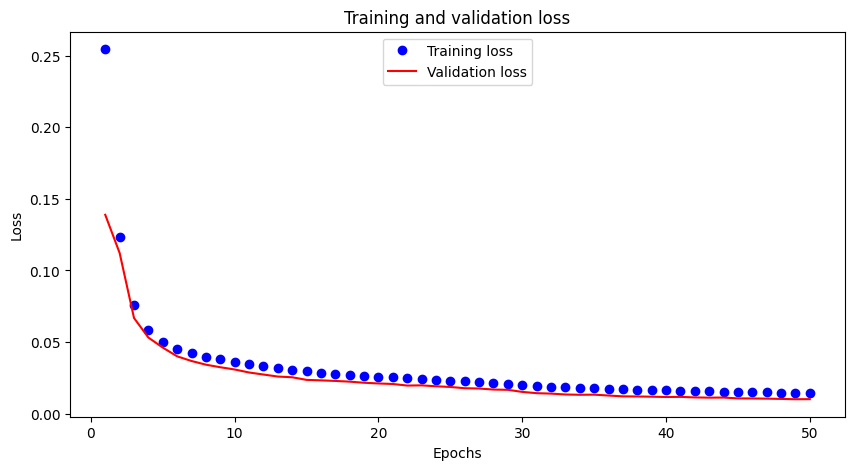

val  MSE=0.010089 | val  MAE=0.054288
test MSE=0.011076     | test MAE=0.057102


In [10]:
import matplotlib.pyplot as plt

def plot_loss(history):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, h['loss'],     'bo', label='Training loss')
    plt.plot(epochs, h['val_loss'], 'r',  label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(loc='upper center')
history = atom_enc_dec.fit(
    train_ds, validation_data=val_ds,
    epochs=50, steps_per_epoch=n_train_steps, validation_steps=n_val_steps,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)],
    verbose=1)

atom_enc_dec.save_weights('atom_enc_dec.weights.h5')
print('Saved.')

plot_loss(history)
plt.savefig('atom_enc_dec.jpg', dpi=300, bbox_inches='tight')
plt.show()

best_val_mse = min(history.history['val_loss'])
val_mae_key  = [k for k in history.history if 'mae' in k and 'val' in k][0]
best_val_mae = min(history.history[val_mae_key])
test_mse, test_mae = atom_enc_dec.evaluate(test_ds, steps=n_test_steps, verbose=0)
print(f'val  MSE={best_val_mse:.6f} | val  MAE={best_val_mae:.6f}')
print(f'test MSE={test_mse:.6f}     | test MAE={test_mae:.6f}')

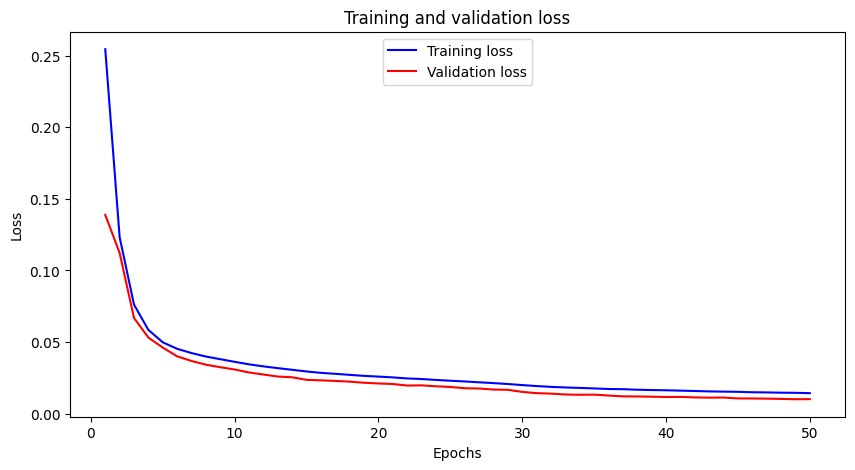

In [11]:
# this cell is the same plot above but just b instead of bo
import matplotlib.pyplot as plt
def plot_loss(history):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, h['loss'],     'b', label='Training loss')
    plt.plot(epochs, h['val_loss'], 'r',  label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(loc='upper center')
plot_loss(history)
plt.savefig('atom_enc_dec.jpg', dpi=300, bbox_inches='tight')
plt.show()





In [12]:
# ===== EXAM CELL =====
exam_model = AtomEncoderDecoder(
    num_layers=1, d_model=32, num_heads=2, dff=64,
    output_dim=9, dropout_rate=0.1)

for (X_enc, X_dec), _ in test_ds.take(1):
    exam_model((X_enc, X_dec), training=False)

exam_model.load_weights('atom_enc_dec.weights.h5')
print('Loaded: atom_enc_dec.weights.h5')

S = SPATIAL_WINDOW
t = T_WINDOW
a = 0   # atom 0

padded_test = np.pad(test_feat, ((0,0),(S,S),(0,0)), mode='edge').astype(np.float32)
x_enc = padded_test[t-T_WINDOW:t, a:a+2*S+1, :].reshape(1, T_WINDOW, -1).astype(np.float32)
x_dec = test_feat[t, a, :].reshape(1, 1, -1).astype(np.float32)

current   = test_feat[t,     a, :]
true_next = test_feat[t + 1, a, :]

pred_delta = exam_model((x_enc, x_dec), training=False).numpy()[0]
pred_next  = current + pred_delta

labels = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'fx', 'fy', 'fz']
print(f'\n{"Feature":<6} {"Current":>10} {"True next":>12} {"Pred next":>12} {"Error":>10}')
print('-' * 55)
for i, label in enumerate(labels):
    print(f'{label:<6} {current[i]:>10.5f} {true_next[i]:>12.5f} '
          f'{pred_next[i]:>12.5f} {abs(pred_next[i]-true_next[i]):>10.5f}')

print(f'\nOverall MAE : {np.mean(np.abs(pred_next - true_next)):.6f}')
print(f'Coord MAE   : {np.mean(np.abs(pred_next[:3] - true_next[:3])):.6f}')
print('\nInference OK!')

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (128, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Loaded: atom_enc_dec.weights.h5

Feature    Current    True next    Pred next      Error
-------------------------------------------------------
x        -3.70193     -3.70195     -3.70193    0.00002
y        -3.69180     -3.69164     -3.69176    0.00012
z        -3.58854     -3.58852     -3.58865    0.00013
vx       -0.20125     -0.02398      0.00907    0.03306
vy        0.37074      0.45334      0.51356    0.06023
vz       -0.01424      0.04972      0.04071    0.00900
fx        1.30836      0.94578      0.92467    0.02110
fy        0.86747      0.94156      0.73512    0.20644
fz        0.37013      0.24535      0.25827    0.01292

Overall MAE : 0.038113
Coord MAE   : 0.000090

Inference OK!


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


The values shown are scaled (StandardScaler normalized), so you won't find them directly in your CSV. You need to inverse transform first to get the original values. You need to inverse transform first to get the original  :
scaler.inverse_transform

 (I will try it after the training of epochs = 100 below end)

Val loss is still decreasing at epoch 50 — EarlyStopping never triggered. Continue training:

I was training the below cell and it arrives to apoch 88 with very good result then I finished the resources of free Gpu on colab
**# See you tmw :)**

Vincenzo said try just 50epochs so I will not try 100

In [ ]:
history2 = atom_enc_dec.fit(
    train_ds, validation_data=val_ds,
    epochs=100,
    steps_per_epoch=n_train_steps,
    validation_steps=n_val_steps,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1)],
    verbose=1,
    initial_epoch=50)

atom_enc_dec.save_weights('atom_enc_dec.weights.h5')
print('Saved.')

test_mse, test_mae = atom_enc_dec.evaluate(test_ds, steps=n_test_steps, verbose=0)
print(f'test MSE={test_mse:.6f} | test MAE={test_mae:.6f}')

NameError: name 'atom_enc_dec' is not defined